# 00 — EDA & Preprocessing


**What this notebook does:**

1. Loads the raw Kaggle CSV via `src.data_loader`.
2. Runs exploratory data analysis — target distribution, missing values, feature
   distributions, correlation, outliers. Saves every figure to `../figures/`.
3. Performs an 80/20 **stratified** train/test split (`random_state=42`).
4. Fits the preprocessing pipeline (median impute → signed log1p → standard
   scale) on the **training set only**, transforms both splits, and persists
   them to `../artifacts/splits/`.
5. Runs sanity checks (no leakage, class proportions preserved, train mean ≈ 0,
   train std ≈ 1).

**Every model notebook (01–05) starts by calling `preprocess.load_splits()` so
they all train on the exact same arrays produced here.**

> Dataset: <https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset> — place `transaction_dataset.csv` in `../data/` before running.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw, TARGET
from src import preprocess

DATA_CSV = PROJECT_ROOT / "data" / "transaction_dataset.csv"
FIG_DIR = PROJECT_ROOT / "figures"
SPLITS_DIR = PROJECT_ROOT / "artifacts" / "splits"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


Matplotlib is building the font cache; this may take a moment.


## 2. Load the data

In [2]:
X, y, n_dropped = load_raw(DATA_CSV)
print(f"Loaded: {X.shape[0]} rows x {X.shape[1]} features")
print(f"Removed {n_dropped} duplicate rows during loading")
print(f"\nFirst 5 columns:\n  " + "\n  ".join(X.columns[:5]))
print(f"\nLast 5 columns:\n  " + "\n  ".join(X.columns[-5:]))
X.head()


Loaded: 9288 rows x 45 features
Removed 553 duplicate rows during loading

First 5 columns:
  Avg min between sent tnx
  Avg min between received tnx
  Time Diff between first and last (Mins)
  Sent tnx
  Received Tnx

Last 5 columns:
  ERC20 min val sent contract
  ERC20 max val sent contract
  ERC20 avg val sent contract
  ERC20 uniq sent token name
  ERC20 uniq rec token name


,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,...,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,...,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0
1,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,...,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0
2,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,...,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0
3,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,...,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0
4,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,...,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0


In [3]:
# Dtypes summary
dtype_counts = X.dtypes.value_counts()
print("Column dtypes:")
print(dtype_counts)


Column dtypes:
float64    39
int64       6
Name: count, dtype: int64


## 3. Target distribution

The dataset is imbalanced — about 22% fraud. This is why we split stratified and why accuracy alone is not enough (§7.2, §11.4 of the requirements).

      count  percent
FLAG                
0      7632    82.17
1      1656    17.83


/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/554571302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#2a9d8f", "#e76f51"])
/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/554571302.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])


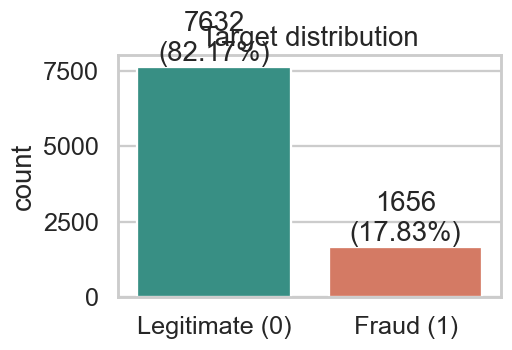

In [4]:
counts = y.value_counts().sort_index()
pcts = (counts / counts.sum() * 100).round(2)
print(pd.DataFrame({"count": counts, "percent": pcts}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#2a9d8f", "#e76f51"])
ax.set_xticklabels(["Legitimate (0)", "Fraud (1)"])
ax.set_xlabel("")
ax.set_ylabel("count")
ax.set_title("Target distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n({pcts.iloc[i]}%)", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_target_distribution.png", bbox_inches="tight")
plt.show()


## 4. Missing values

ERC20 columns are NaN for addresses that never touched a token contract — that's domain-meaningful, not random missingness. We impute with the training-set **median** in §10. Non-ERC20 columns should be NaN-free.

In [5]:
na = X.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print(f"{len(na)} columns with missing values (total {na.sum()} NaNs):")
print(na.to_string())


23 columns with missing values (total 12627 NaNs):
Total ERC20 tnxs                       549
ERC20 min val rec                      549
ERC20 uniq sent token name             549
ERC20 avg val sent contract            549
ERC20 max val sent contract            549
ERC20 min val sent contract            549
ERC20 avg val sent                     549
ERC20 max val sent                     549
ERC20 min val sent                     549
ERC20 avg val rec                      549
ERC20 max val rec                      549
ERC20 avg time between contract tnx    549
ERC20 total Ether received             549
ERC20 avg time between rec 2 tnx       549
ERC20 avg time between rec tnx         549
ERC20 avg time between sent tnx        549
ERC20 uniq rec contract addr           549
ERC20 uniq sent addr.1                 549
ERC20 uniq rec addr                    549
ERC20 uniq sent addr                   549
ERC20 total Ether sent contract        549
ERC20 total ether sent                 549
ERC

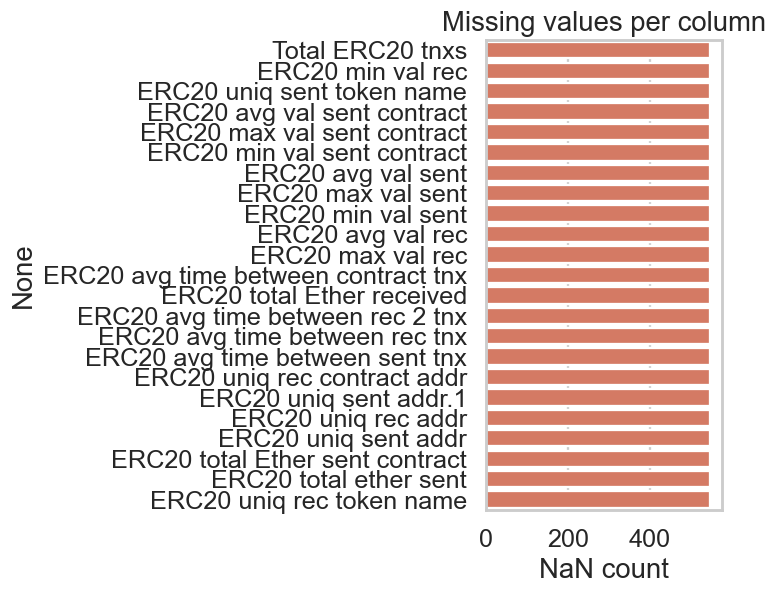

In [6]:
if len(na) > 0:
    fig, ax = plt.subplots(figsize=(7, max(3, len(na) * 0.25)))
    sns.barplot(x=na.values, y=na.index, ax=ax, color="#e76f51")
    ax.set_xlabel("NaN count")
    ax.set_title("Missing values per column")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "eda_missing_values.png", bbox_inches="tight")
    plt.show()
else:
    print("No missing values.")


## 5. Numeric summary & skewness

The Ether-value and transaction-count features are heavy right-tailed. We log1p them before scaling so KNN/LR/SVM don't get dominated by a few outliers.

In [7]:
desc = X.describe().T[["mean", "std", "min", "50%", "max"]]
desc["skew"] = X.skew(numeric_only=True)
desc = desc.sort_values("skew", ascending=False)
print("Top 10 most right-skewed features:")
print(desc.head(10).round(2))


Top 10 most right-skewed features:
                                    mean           std  min   50%  \
avg val received            1.064200e+02  2.969520e+03  0.0  2.08   
ERC20 avg val sent          6.515748e+06  6.006440e+08  0.0  0.00   
ERC20 max val sent          1.344115e+07  1.198193e+09  0.0  0.00   
ERC20 min val sent          1.210803e+04  1.069897e+06  0.0  0.00   
ERC20 max val rec           1.291645e+08  1.070073e+10  0.0  0.00   
ERC20 total Ether received  1.336688e+08  1.070192e+10  0.0  0.00   
ERC20 total ether sent      1.429914e+07  1.198685e+09  0.0  0.00   
min value sent to contract  0.000000e+00  0.000000e+00  0.0  0.00   
max val sent to contract    0.000000e+00  0.000000e+00  0.0  0.00   
total ether sent contracts  0.000000e+00  0.000000e+00  0.0  0.00   

                                     max   skew  
avg val received            2.836188e+05  93.77  
ERC20 avg val sent          5.614756e+10  93.47  
ERC20 max val sent          1.120000e+11  93.46  
ERC20

## 6. Feature distributions by class

We overlay legit vs fraud for a handful of high-signal features. log1p applied for readability.

Plotting 8 features.


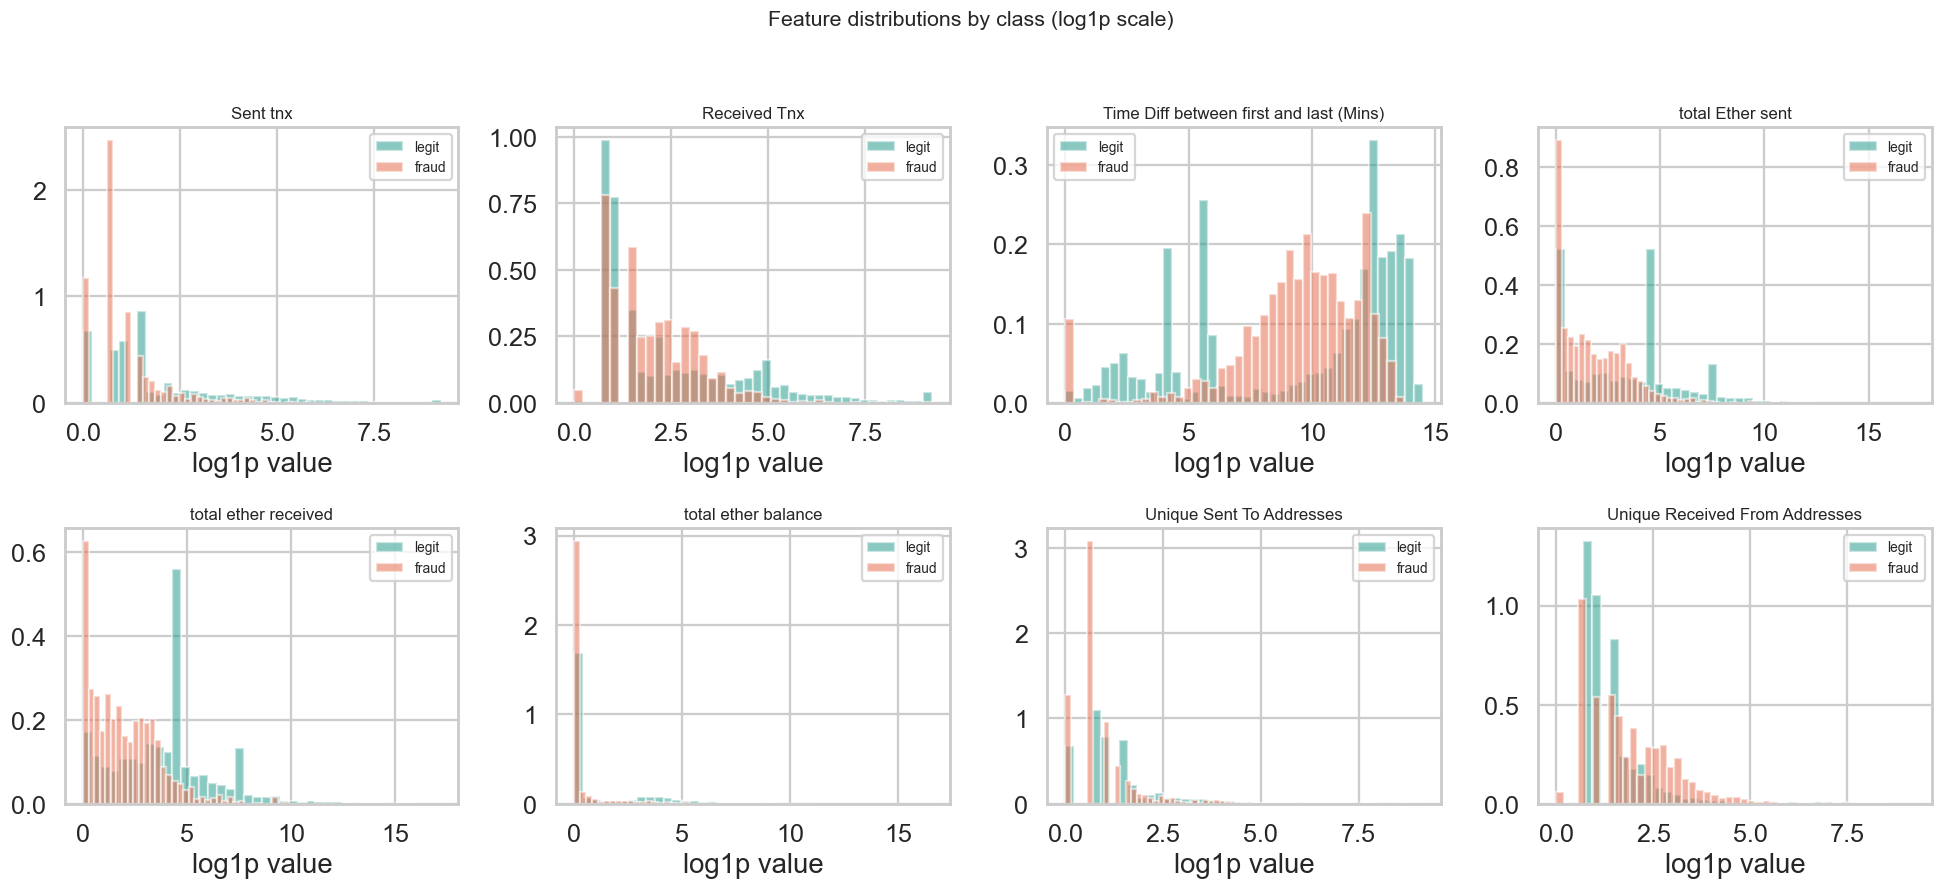

In [8]:
TOP_FEATURES = [
    "Sent tnx",
    "Received Tnx",
    "Time Diff between first and last (Mins)",
    "total Ether sent",
    "total ether received",
    "total ether balance",
    "Unique Sent To Addresses",
    "Unique Received From Addresses",
]
present = [c for c in TOP_FEATURES if c in X.columns]
print(f"Plotting {len(present)} features.")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, present):
    legit = np.log1p(np.abs(X.loc[y == 0, col].fillna(0).to_numpy()))
    fraud = np.log1p(np.abs(X.loc[y == 1, col].fillna(0).to_numpy()))
    ax.hist(legit, bins=40, alpha=0.55, label="legit", color="#2a9d8f", density=True)
    ax.hist(fraud, bins=40, alpha=0.55, label="fraud", color="#e76f51", density=True)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("log1p value")
    ax.legend(fontsize=9)
for ax in axes.flat[len(present):]:
    ax.axis("off")
fig.suptitle("Feature distributions by class (log1p scale)", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_feature_distributions_by_class.png", bbox_inches="tight")
plt.show()


## 7. Correlation heatmap

High-correlation pairs flag redundant features. We don't drop any here — the tree models will down-weight them automatically — but it's useful context for the report.

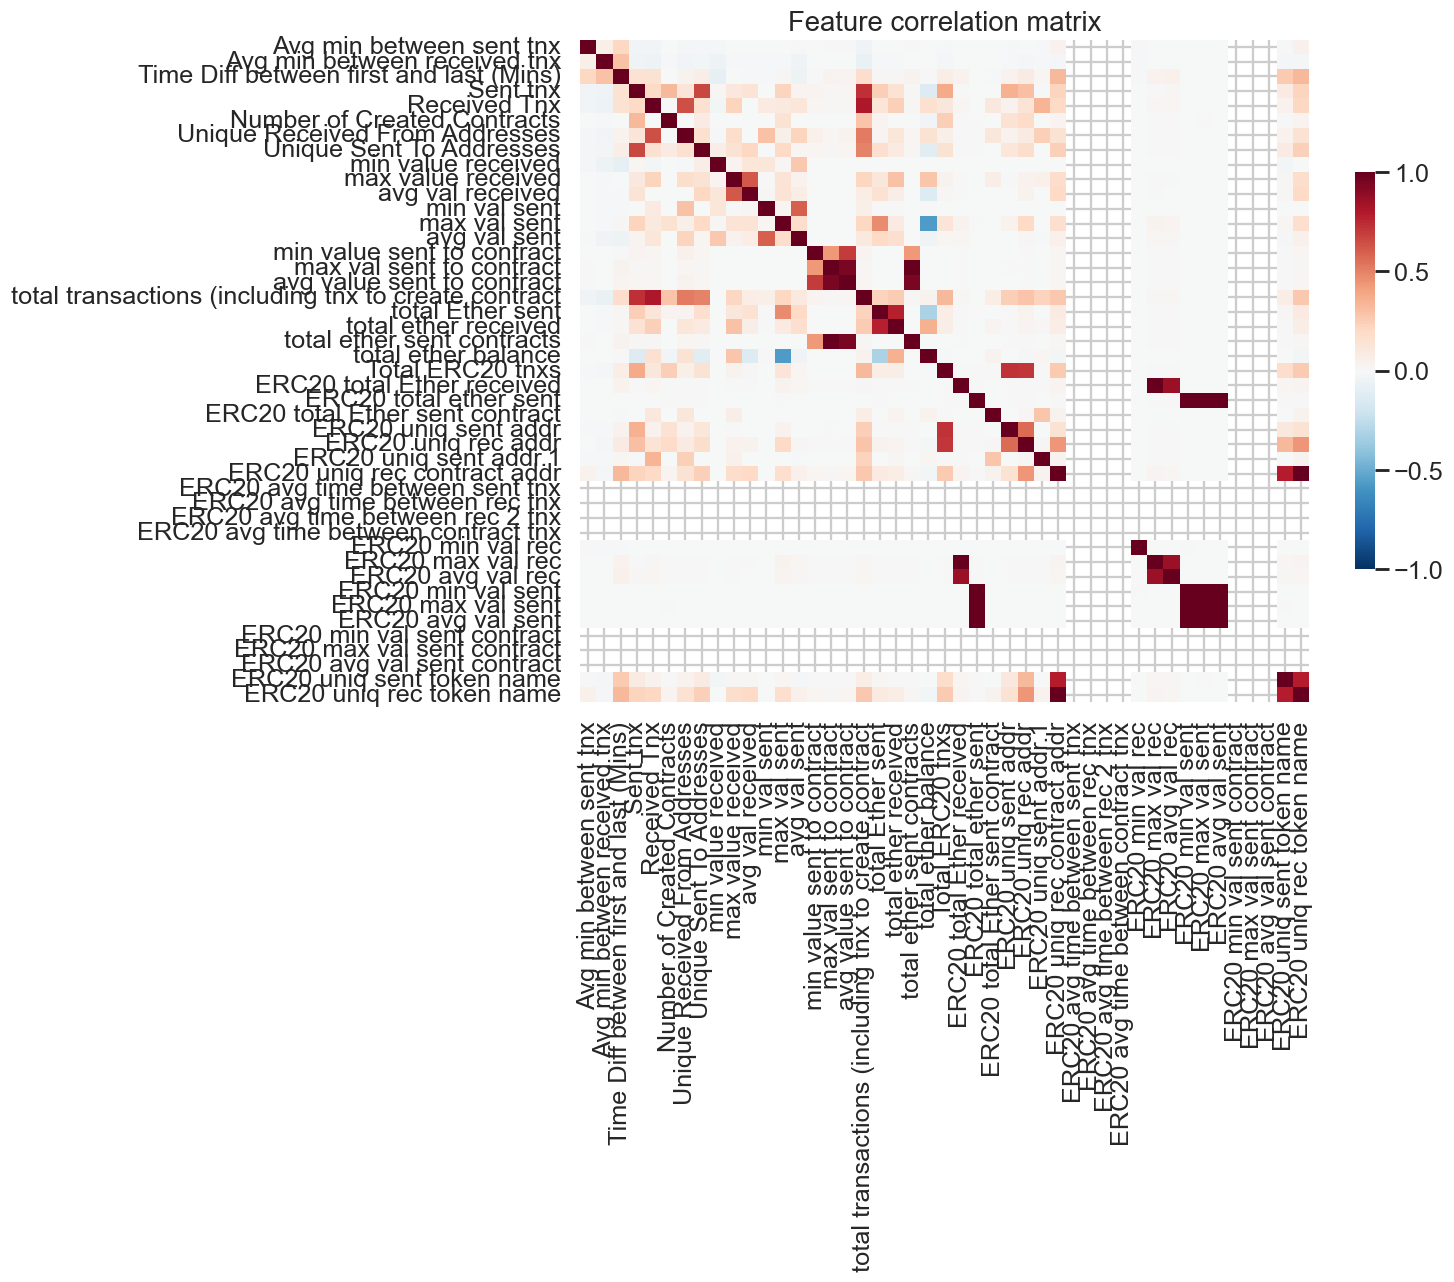


Highly correlated pairs (|r| > 0.95):
max val sent to contract      total ether sent contracts    1.000000
ERC20 total Ether received    ERC20 max val rec             0.999967
ERC20 max val sent            ERC20 avg val sent            0.999952
ERC20 min val sent            ERC20 avg val sent            0.999785
                              ERC20 max val sent            0.999729
ERC20 total ether sent        ERC20 max val sent            0.999649
ERC20 uniq rec contract addr  ERC20 uniq rec token name     0.999642
ERC20 total ether sent        ERC20 avg val sent            0.999566
                              ERC20 min val sent            0.999311
dtype: float64


In [9]:
corr = X.fillna(0).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Pairs with |r| > 0.95 (excluding self)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
high = (corr.where(mask)
        .stack()
        .loc[lambda s: s.abs() > 0.95]
        .sort_values(key=abs, ascending=False))
print("\nHighly correlated pairs (|r| > 0.95):")
print(high.head(15))


## 8. Outlier boxplots (top-skewed features)

/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/766651918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=vals, ax=ax, palette=["#2a9d8f", "#e76f51"])
/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/766651918.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["legit", "fraud"])
/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/766651918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=vals, ax=ax, palette=["#2a9d8f", "#e76f51"])
/var/folders/1n/0rtrr2_54z1ddff1lxrzbbm00000gn/T/ipykernel_47168/766651918.py:8: UserWarni

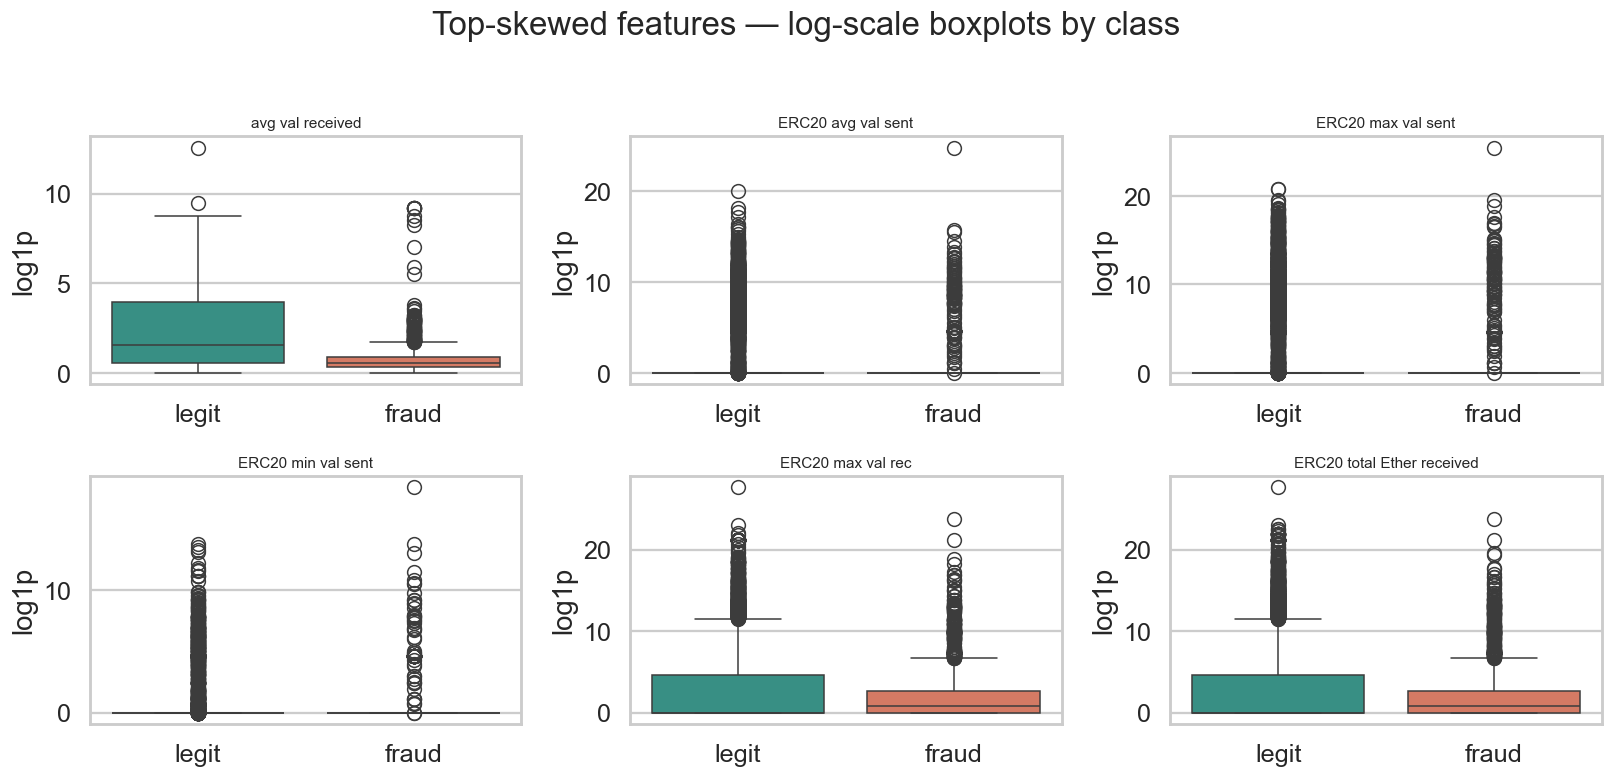

In [10]:
top_skew = desc.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, top_skew):
    vals = np.log1p(np.abs(X[col].fillna(0).to_numpy()))
    sns.boxplot(x=y, y=vals, ax=ax, palette=["#2a9d8f", "#e76f51"])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("log1p")
    ax.set_xticklabels(["legit", "fraud"])
fig.suptitle("Top-skewed features — log-scale boxplots by class", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_outlier_boxplots.png", bbox_inches="tight")
plt.show()


## 9. Train/test split

80/20 **stratified** on `FLAG` so the class proportion is identical in both
parts (§7.2). The split is the only place a `random_state` lives in this
project — every downstream notebook seeds CV with the same `42`.

**Critical rule (§7.3):** nothing fitted below sees `X_test` until §10
applies a pre-fitted `transform`.

In [11]:
X_train, X_test, y_train, y_test = preprocess.stratified_split(X, y)

split_summary = pd.DataFrame({
    "n_rows": [len(X_train), len(X_test)],
    "n_fraud": [int(y_train.sum()), int(y_test.sum())],
    "fraud_pct": [y_train.mean() * 100, y_test.mean() * 100],
}, index=["train", "test"]).round(3)
print(split_summary)

assert abs(y_train.mean() - y_test.mean()) < 0.005, "Stratification failed"
print("\nStratification check passed: train/test fraud rates within 0.5pp.")


       n_rows  n_fraud  fraud_pct
train    7430     1325     17.833
test     1858      331     17.815

Stratification check passed: train/test fraud rates within 0.5pp.


## 10. Fit preprocessing on TRAIN only, transform both, save

Pipeline: `SimpleImputer(median)` → `signed log1p` → `StandardScaler`.

All three steps are fitted from `X_train` only. The fitted
`ColumnTransformer` is saved to `artifacts/splits/preprocessor.joblib` so
new data can later be transformed with the exact same statistics.

In [12]:
out = preprocess.fit_transform_save(
    X_train, X_test, y_train, y_test,
    output_dir=SPLITS_DIR,
)

X_train_proc = out["X_train"]
X_test_proc = out["X_test"]
feature_names = out["feature_names"]

print(f"Saved to: {SPLITS_DIR}")
for p in sorted(SPLITS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<24} {size_kb:>8.1f} KB")

print(f"\nProcessed shapes: train={X_train_proc.shape}, test={X_test_proc.shape}")
print(f"Number of features after preprocessing: {len(feature_names)}")


Saved to: /Users/akash/Documents/fintech/eth_fraud_project/artifacts/splits
  feature_names.txt             1.1 KB
  preprocessor.joblib           7.2 KB
  splits.npz                  502.7 KB

Processed shapes: train=(7430, 45), test=(1858, 45)
Number of features after preprocessing: 45


## 11. Sanity checks

In [13]:
# (a) no NaN survived
assert not np.isnan(X_train_proc).any(), "NaN in processed train!"
assert not np.isnan(X_test_proc).any(),  "NaN in processed test!"

# (b) scaler statistics fit on train only.
# StandardScaler leaves zero-variance columns at scale=1 (they stay all-zeros),
# so we exclude them when checking std ~= 1.
train_mean = X_train_proc.mean(axis=0)
train_std  = X_train_proc.std(axis=0)
const_mask = train_std < 1e-8
n_const = int(const_mask.sum())
print(f"Train mean per col: max |mean| = {np.abs(train_mean).max():.2e}   (should be ~0)")
print(f"Constant columns in train (no signal, kept for schema): {n_const}")
if n_const > 0:
    const_cols = [feature_names[i] for i, c in enumerate(const_mask) if c]
    print(f"  -> {const_cols}")
print(f"Non-constant cols: std mean = {train_std[~const_mask].mean():.4f}  (should be ~1)")
assert np.abs(train_mean).max() < 1e-6, "Train mean drifted from 0"
assert abs(train_std[~const_mask].mean() - 1.0) < 1e-2, "Train std drifted from 1 on non-constant cols"

# (c) test stats should be CLOSE to train stats but not identical --
# this confirms the scaler was NOT refit on test.
test_mean = X_test_proc.mean(axis=0)
test_std  = X_test_proc.std(axis=0)
print(f"Test  mean per col: avg |mean| = {np.abs(test_mean).mean():.4f}  (small but nonzero is correct)")
print(f"Test  std  per col (non-const): mean = {test_std[~const_mask].mean():.4f}  (close to 1 but not exactly 1)")

# (d) round-trip via load_splits
reloaded = preprocess.load_splits(SPLITS_DIR)
np.testing.assert_allclose(reloaded["X_train"], X_train_proc, rtol=1e-5)
np.testing.assert_array_equal(reloaded["y_train"], y_train.to_numpy())
print("\nload_splits() round-trip OK.")


Train mean per col: max |mean| = 2.33e-16   (should be ~0)
Constant columns in train (no signal, kept for schema): 7
  -> ['ERC20 avg time between sent tnx', 'ERC20 avg time between rec tnx', 'ERC20 avg time between rec 2 tnx', 'ERC20 avg time between contract tnx', 'ERC20 min val sent contract', 'ERC20 max val sent contract', 'ERC20 avg val sent contract']
Non-constant cols: std mean = 1.0000  (should be ~1)
Test  mean per col: avg |mean| = 0.0138  (small but nonzero is correct)
Test  std  per col (non-const): mean = 0.9655  (close to 1 but not exactly 1)

load_splits() round-trip OK.


## 12. Summary for the report

| Item | Value |
| --- | --- |
| Rows (after dedupe) | shown in §2 |
| Numeric features | shown in §2 |
| Target | `FLAG` (binary, imbalanced — see §3) |
| Train / test split | 80 / 20 stratified, `random_state=42` |
| Missing values | median-imputed (train medians only) |
| Skew handling | signed `log1p` on all numeric features |
| Scaling | `StandardScaler` fitted on train only |
| Imbalance | handled per-model (next notebooks) |

**Hand-off to model notebooks:** every subsequent notebook loads its data
with:

```python
from src.preprocess import load_splits
data = load_splits("../artifacts/splits")
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
```

Do **not** re-split, re-impute, or re-scale in model notebooks. The
splits saved here are the single source of truth for the comparison
in notebook 06.